In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torch_geometric.datasets as datasets
from torch_geometric.nn import GCNConv

In [14]:
import torch
import pandas as pd
import networkx as nx
# 加载数据集
#dataset = datasets.Actor(root='data/Actor') #feat #d
#dataset = datasets.Amazon(root='data/AmazonComputers', name='Computers') #feat #d
#dataset = datasets.Amazon(root='data/AmazonPhoto', name='Photo') #feat #d
#dataset = datasets.AttributedGraphDataset(root='data/BlogCatalog',name='BlogCatalog') #feat #d
#dataset = datasets.Planetoid(root='data/CiteSeer', name='CiteSeer') #feat #d
#dataset = datasets.Coauthor(root='data/CoauthorCS', name='CS') #feat #d
#dataset = datasets.Coauthor(root='data/CoauthorPhy', name='Physics') #feat #d
#dataset = datasets.Planetoid(root='data/Cora', name='Cora') #feat #d
#dataset = datasets.WebKB(root='data/Cornell',name='Cornell') #feat #d
#dataset = datasets.CitationFull(root='data/DBLP',name='DBLP') #feat #d
#dataset = datasets.AttributedGraphDataset(root='data/facebook',name='facebook') #feat #d
#dataset = datasets.HeterophilousGraphDataset(root='data/Minesweeper',name='Minesweeper') #feat #d
#dataset = datasets.NELL(root='data/NELL') #d #feat跑不出来
#dataset = datasets.Planetoid(root='data/pubmed',name='pubmed') #feat #d
#dataset = datasets.WebKB(root='data/Texas',name='Texas') #feat #d
#dataset = datasets.AttributedGraphDataset(root='data/Wiki',name='Wiki') #feat #d
#dataset = datasets.WebKB(root='data/Wisconsin',name='Wisconsin') #feat #d
dataset = datasets.KarateClub()
file_name = 'KarateClub'

data = dataset[0]
print(data)
print(file_name)

# 转换为 NetworkX 图（无向图）
edge_index = data.edge_index
G = nx.Graph()
G.add_nodes_from(range(data.num_nodes))
G.add_edges_from(edge_index.t().tolist())

# 计算度中心性（每个节点的连接边数归一化）
degree = nx.degree_centrality(G)
degree_df = pd.DataFrame({'node': list(degree.keys()), 'score': list(degree.values())})
degree_df = degree_df.sort_values(by='score', ascending=False).reset_index(drop=True)

# 计算 PageRank（随机游走模型）
pagerank = nx.pagerank(G, alpha=0.85)
pagerank_df = pd.DataFrame({'node': list(pagerank.keys()), 'score': list(pagerank.values())})
pagerank_df = pagerank_df.sort_values(by='score', ascending=False).reset_index(drop=True)

# 计算介数中心性
betweenness = nx.betweenness_centrality(G)
betweenness_df = pd.DataFrame({'node': list(betweenness.keys()), 'score': list(betweenness.values())})
betweenness_df = betweenness_df.sort_values(by='score', ascending=False).reset_index(drop=True)

# 计算特征向量中心性（幂迭代法）
eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
eigenvector_df = pd.DataFrame({'node': list(eigenvector.keys()), 'score': list(eigenvector.values())})
eigenvector_df = eigenvector_df.sort_values(by='score', ascending=False).reset_index(drop=True)

# 保存结果为 CSV（可选）
betweenness_df.to_csv(f"rank/betweenness/rank_{file_name}_betweenness.csv", index=False)
eigenvector_df.to_csv(f"rank/eigenvector/rank_{file_name}_eigenvector.csv", index=False)
degree_df.to_csv(f"rank/degree/rank_{file_name}_degree.csv", index=False)
pagerank_df.to_csv(f"rank/pagerank/rank_{file_name}_pagerank.csv", index=False)

print("success")


Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
KarateClub
success


In [4]:
# 数据输入
#dataset = datasets.Planetoid(root='data/Cora', name='Cora') #feat
#dataset = datasets.Planetoid(root='data/CiteSeer', name='CiteSeer') #feat
#dataset = datasets.Planetoid(root='data/pubmed',name='pubmed')
#dataset = datasets.CitationFull(root='data/DBLP',name='DBLP') #feat
#dataset = datasets.Coauthor(root='data/CoauthorCS', name='CS') #feat
#dataset = datasets.Coauthor(root='data/CoauthorPhy', name='Physics') #feat
#dataset = datasets.Actor(root='data/Actor') #feat
#dataset = datasets.Amazon(root='data/AmazonComputers', name='Computers') #feat
#dataset = datasets.Amazon(root='data/AmazonPhoto', name='Photo') #feat
#dataset = datasets.AttributedGraphDataset(root='data/BlogCatalog',name='BlogCatalog') #feat
#dataset = datasets.AttributedGraphDataset(root='data/facebook',name='facebook') #feat
#dataset = datasets.AttributedGraphDataset(root='data/Wiki',name='Wiki')
#dataset = datasets.WebKB(root='data/Cornell',name='Cornell') #feat
#dataset = datasets.WebKB(root='data/Texas',name='Texas')
#dataset = datasets.WebKB(root='data/Wisconsin',name='Wisconsin')
dataset = datasets.KarateClub()
file_name = 'KarateClub'

data = dataset[0]
print(data)
print(file_name)

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
KarateClub


In [5]:
# 构建全1属性
uniform_x = torch.ones_like(data.x)
print(uniform_x.shape)

torch.Size([34, 34])


In [6]:
# GCN结构框架
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)
    
class ProjectionHead(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(in_channels, hidden_channels),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_channels, hidden_channels),
        )
        
    def forward(self, x):
        return self.mlp(x)

In [7]:
# 对比学习的损失函数 最大化相似样本之间的互信息，同时最小化非相似样本之间的相关性
def info_nce_loss(z1, z2, temperature=0.5):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    sim_matrix = torch.mm(z1, z2.t()) / temperature
    # 每个节点结构与所有节点特征之间的余弦相似度
    # 目标是最大化 sim(i, i)，最小化其余 sim(i, j≠i)
    labels = torch.arange(z1.size(0))
    loss_1 = F.cross_entropy(sim_matrix, labels)
    loss_2 = F.cross_entropy(sim_matrix.t(), labels)
    return (loss_1 + loss_2) / 2
    # 双向 InfoNCE

In [8]:
#gcn = GCN(dataset.num_features, 128, 64)
#self = GCN(dataset.num_features, 128, 64)
gcn = GCN(len(data.x[1]), 128, 64)
self = GCN(len(uniform_x[1]), 128, 64)
proj_head_gcn = ProjectionHead(64, 64, 64)
proj_head_self = ProjectionHead(64, 64, 64)

optimizer = torch.optim.Adam(list(gcn.parameters()) + list(self.parameters()), lr=0.01)

In [9]:
# 模型训练
for epoch in range(1, 201):
    gcn.train()
    self.train()
    proj_head_gcn.train()
    proj_head_self.train()
    
    optimizer.zero_grad()
    
    #z_struct = gcn(data.x, data.edge_index)
    #z_feat = self(data.x, self_loop_edge_index)
    
    h1 = gcn(data.x, data.edge_index)
    z1 = proj_head_gcn(h1)

    h2 = self(uniform_x, data.edge_index)
    z2 = proj_head_self(h2)
    
    #loss = info_nce_loss(z_struct, z_feat)
    loss = info_nce_loss(z1, z2)
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.8f}')

Epoch 20, Loss: 3.35964632
Epoch 40, Loss: 3.22688484
Epoch 60, Loss: 3.14595509
Epoch 80, Loss: 3.08405757
Epoch 100, Loss: 3.02850151
Epoch 120, Loss: 3.00466371
Epoch 140, Loss: 2.98633099
Epoch 160, Loss: 2.96264267
Epoch 180, Loss: 2.94241667
Epoch 200, Loss: 2.92353225


In [10]:
gcn.eval()
self.eval()
with torch.no_grad():
    z_s = gcn(data.x, data.edge_index)
    z_f = self(uniform_x, data.edge_index)
    diff_score = torch.norm(z_s - z_f, dim=1)  # L2 差异度
# 如果某个节点的结构特征和属性特征差异大，说明它在图中的结构角色与属性角色不一致

In [11]:
# 将分数和索引组合
node_ids = torch.arange(data.num_nodes)
importance_list = list(zip(node_ids.numpy(), diff_score.numpy()))

# 按分数降序排序
importance_sorted = sorted(importance_list, key=lambda x: x[1], reverse=True)

# 打印 Top 10 重要节点
print("Top 10 important nodes:")
for rank, (node_id, score) in enumerate(importance_sorted[:10], 1):
    print(f"Rank {rank}: Node {node_id}, Score: {score:.4f}")

Top 10 important nodes:
Rank 1: Node 33, Score: 48.3274
Rank 2: Node 32, Score: 38.6879
Rank 3: Node 25, Score: 37.7685
Rank 4: Node 24, Score: 37.1073
Rank 5: Node 0, Score: 36.9797
Rank 6: Node 27, Score: 32.3338
Rank 7: Node 23, Score: 31.4122
Rank 8: Node 2, Score: 28.6751
Rank 9: Node 1, Score: 28.4526
Rank 10: Node 31, Score: 24.1166


In [12]:
# 构建 DataFrame
df = pd.DataFrame(importance_sorted, columns=["node", "score"])

# 保存为 CSV 文件
df.to_csv(f"rank/diff_feat/rank_{file_name}_feat.csv", index=False)

In [56]:
#打印对比相关性系数的CSV文件
import pandas as pd
import numpy as np
from scipy.stats import kendalltau, spearmanr

# 文件路径列表（替换为你的实际文件名）
#typename = file_name
typename = 'Wisconsin'

file_paths = [
    f"rank/diff_struct/rank_{typename}_struct.csv",
#    f"rank/diff_feat/rank_{typename}_feat.csv",
    f"rank/degree/rank_{typename}_degree.csv",
    f"rank/pagerank/rank_{typename}_pagerank.csv",
    f"rank/betweenness/rank_{typename}_betweenness.csv",
    f"rank/HVGC/rank_{typename}_HVGC.csv",
    f"rank/GNR/rank_{typename}_GNR.csv",
    f"rank/mini/rank_{typename}_mini.csv",
    f"rank/HHGNN/rank_{typename}_HHGNN.csv",
    f"rank/CNT/rank_{typename}_CNT.csv",
    f"rank/CLMA/rank_{typename}_CLMA.csv",
    f"rank/CGNN/rank_{typename}_CGNN.csv",
]

file_labels = [
    'struct_weak',
#    'Ours',
    'degree',
    'pagerank',
    'betweenness',
    'HVGC',
    'GNR',
    'mini-batch',
    'HHGNN',
    'CNT',
    'CLMA',
    'CGNN',
]

# 提取文件名作为标签
labels = file_labels

# 读取每个文件的 node 列顺序
rankings = []
for path in file_paths:
    df = pd.read_csv(path)
    rankings.append(list(df['node']))

# 假设所有排名中节点完全一致
nodes = rankings[0]

# 构建每个排名的 node -> rank 映射
ranking_dicts = []
for rank in rankings:
    ranking_dicts.append({node: i for i, node in enumerate(rank)})

# 构建排名的数组形式
ranking_arrays = []
for rank_dict in ranking_dicts:
    ranking_arrays.append([rank_dict[node] for node in nodes])

ranking_arrays = np.array(ranking_arrays)

# 初始化结果矩阵
n = len(ranking_arrays)
kendall_matrix = np.zeros((n, n))
spearman_matrix = np.zeros((n, n))

# 计算系数
for i in range(n):
    for j in range(n):
        kendall_matrix[i, j], _ = kendalltau(ranking_arrays[i], ranking_arrays[j])
        spearman_matrix[i, j], _ = spearmanr(ranking_arrays[i], ranking_arrays[j])

# 转为 DataFrame 加上标签
kendall_df = pd.DataFrame(kendall_matrix, index=labels, columns=labels)
spearman_df = pd.DataFrame(spearman_matrix, index=labels, columns=labels)

print(f"{typename}\n")
print(kendall_df.round(4))
print(spearman_df.round(4))

# 如果需要保存为 CSV 文件：
kendall_df.to_csv(f"struct/kendall_{typename}.csv",float_format="%.4f")
spearman_df.to_csv(f"struct/spearman_{typename}.csv",float_format="%.4f")
#kendall_df.to_csv(f"correlation_analysis/kendall_{typename}.csv",float_format="%.4f")
#spearman_df.to_csv(f"correlation_analysis/spearman_{typename}.csv",float_format="%.4f")
#kendall_df.to_csv(f"ablation/result/struct_ablation_k_{typename}.csv",float_format="%.4f")
#spearman_df.to_csv(f"ablation/result/struct_ablation_s_{typename}.csv",float_format="%.4f")

Wisconsin

             struct_weak  degree  pagerank  betweenness    HVGC     GNR  \
struct_weak       1.0000  0.2284    0.2681       0.2356  0.0884  0.1995   
degree            0.2284  1.0000    0.8132       0.5724  0.4873  0.3810   
pagerank          0.2681  0.8132    1.0000       0.6033  0.4266  0.4005   
betweenness       0.2356  0.5724    0.6033       1.0000  0.3981  0.3700   
HVGC              0.0884  0.4873    0.4266       0.3981  1.0000  0.1707   
GNR               0.1995  0.3810    0.4005       0.3700  0.1707  1.0000   
mini-batch       -0.0053 -0.0150   -0.0423       0.0202  0.3094 -0.0635   
HHGNN             0.0657  0.3945    0.3861       0.2940  0.2222  0.2258   
CNT               0.0771  0.5027    0.4478       0.4193  0.8142  0.1805   
CLMA              0.2433  0.3263    0.3487       0.2699  0.2970  0.2074   
CGNN              0.0819  0.4498    0.4454       0.2834  0.1986  0.2352   

             mini-batch   HHGNN     CNT    CLMA    CGNN  
struct_weak     -0.0053  0.065

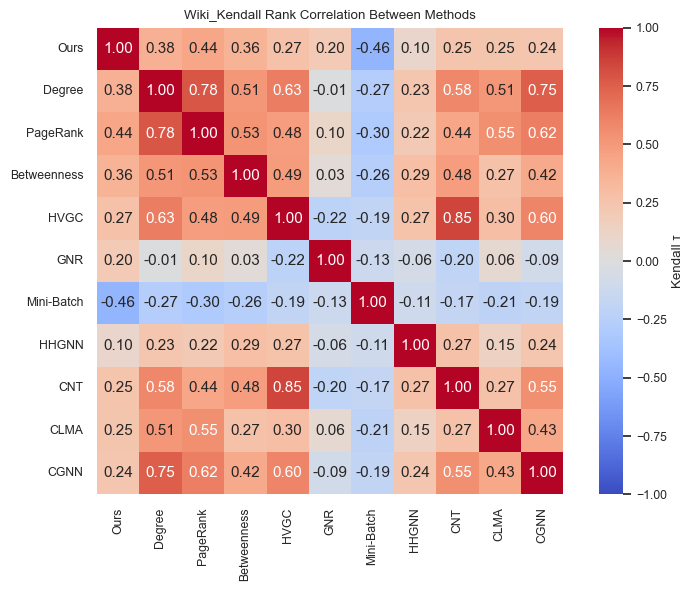

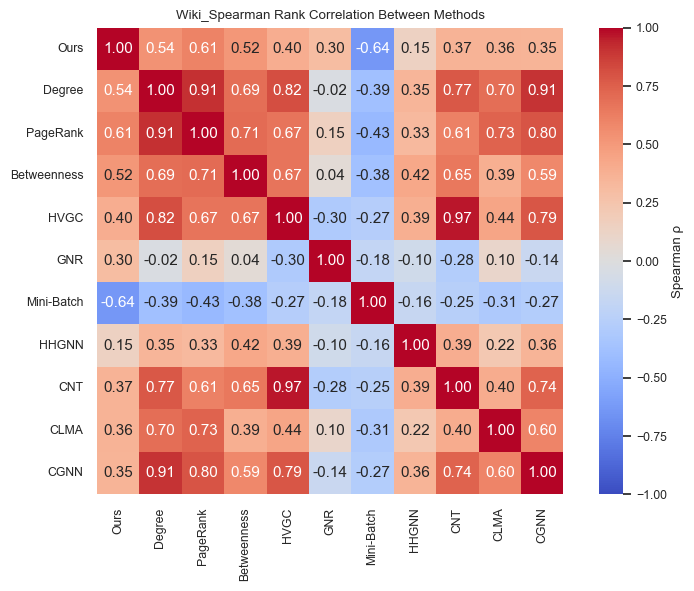

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

batch = "a"
index = "Wiki"
dff = pd.read_csv(f"correlation_analysis/kendall_{index}.csv", index_col=0)
dfff = pd.read_csv(f"correlation_analysis/spearman_{index}.csv", index_col=0)

rename_dict = {
    "Ours": "Ours",
    "degree": "Degree",
    "pagerank": "PageRank",
    "betweenness": "Betweenness",
    "HVGC": "HVGC",
    "GNR": "GNR",
    "mini-batch": "Mini-Batch",
    "HHGNN": "HHGNN",
    "CNT":"CNT",
    "CLMA": "CLMA",
    "CGNN": "CGNN"
}

#selected_methods = ["struct_weak", "laplacian", "variance", "degree", "pagerank"]
selected_methods = ["Ours", "degree", "pagerank", "betweenness", "HVGC", "GNR", "mini-batch", "HHGNN", "CNT", "CLMA", "CGNN"]
sub_df = dff.loc[selected_methods, selected_methods]
sub_dff = dfff.loc[selected_methods, selected_methods]

sub_df = sub_df.rename(index=rename_dict, columns=rename_dict)
sub_dff = sub_dff.rename(index=rename_dict, columns=rename_dict)

sns.set(font_scale=0.8)
plt.figure(1,figsize=(8, 6))
sns.heatmap(sub_df, annot=True,annot_kws={"size": 11}, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, cbar_kws={'label': 'Kendall τ'})
plt.title(f"{index}_Kendall Rank Correlation Between Methods")
plt.tight_layout()
plt.savefig(f"heatmap/Kendall/fouth/{batch}_{index}.png", dpi=300, bbox_inches='tight')

plt.figure(2,figsize=(8, 6))
sns.heatmap(sub_dff, annot=True,annot_kws={"size": 11}, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, cbar_kws={'label': 'Spearman ρ'})
plt.title(f"{index}_Spearman Rank Correlation Between Methods")
plt.tight_layout()
plt.savefig(f"heatmap/Spearman/fouth/{batch}_{index}.png", dpi=300, bbox_inches='tight')
plt.show()

In [3]:
# 拼接图片
from PIL import Image
import os

# 图像路径列表（假设你图片命名为 fig1.png, fig2.png, ..., fig15.png）
#image_folder = "heatmap/Kendall/fouth"
image_index = "GCC"
#image_folder = f"SIR_result/fix/ratio_fig"
image_folder = f"try/gcc/fig"
#image_files = [f"{image_index}_Cora.png",f"{image_index}_CiteSeer.png",f"{image_index}_pubmed.png",f"{image_index}_DBLP.png",f"{image_index}_CoauthorCS.png",f"{image_index}_CoauthorPhy.png"]
#image_files = [f"{image_index}_Actor.png",f"{image_index}_AmazonComputers.png",f"{image_index}_AmazonPhoto.png",f"{image_index}_BlogCatalog.png",f"{image_index}_facebook.png",f"{image_index}_Wiki.png"]

image_files = [f"{image_index}_Cora.png",f"{image_index}_CiteSeer.png",f"{image_index}_pubmed.png",f"{image_index}_DBLP.png",f"{image_index}_CoauthorCS.png",f"{image_index}_CoauthorPhy.png",f"{image_index}_Actor.png",f"{image_index}_AmazonComputers.png",f"{image_index}_AmazonPhoto.png"]
image_paths = [os.path.join(image_folder, f) for f in image_files]

# 打开所有图像
images = [Image.open(p) for p in image_paths]

# 假设所有图像大小一致（建议提前 resize 统一）
img_width, img_height = images[0].size

# 拼接设置：4行3列
rows, cols = 3, 3
assert len(images) <= rows * cols, "图像数量超过指定网格！"

# 创建拼接图像的画布
result_width = cols * img_width
result_height = rows * img_height
result = Image.new('RGB', (result_width, result_height), color=(255, 255, 255))

# 将每张图粘贴到对应位置
for idx, img in enumerate(images):
    row = idx // cols
    col = idx % cols
    result.paste(img, (col * img_width, row * img_height))

# 保存大图
#result.save(f"heatmap/result/b_spearman_PIL.png")
#result.save(f"heatmap/result/b_kendall_PIL.png", dpi=(300,300))
#result.save(f"SIR_result/fix/ratio_PIL.png", dpi=(300,300))
#result.save(f"GCC_result/GCC_PIL.png", dpi=(300,300))
result.save(f"try/gcc/gcc_PIL.png", dpi=(300,300))
result.show()


In [24]:
#SIR 把ours放到最高层
import matplotlib.pyplot as plt
import pandas as pd

new_colors = [
    '#d62728',
    '#1f77b4',  # 原第1个（蓝）
    '#ff7f0e',  # 原第2个（橙黄）
    '#2ca02c',  # 原第3个（绿）
    '#9467bd',  # 原第5个（紫）→ 替换原第4个红色
    '#8c564b',  # 原第6个（棕）
    '#e377c2',   # 原第7个（粉）
    '#808080'
]
markers = ['s', 'o', '^', 'D', 'v', '*', 'P', 'X', 'p', 'h']

names = "Wiki"
time_range = list(range(1, 11, 1))  # [1,6,11,...,46]
seed_ratios = [0.01, 0.05, 0.1, 0.15, 0.2]
ours_time = pd.read_csv(f"SIR_result/AttrWeak/time/time_{names}.csv", index_col = 0)
ours_ratio = pd.read_csv(f"SIR_result/AttrWeak/ratio/ratio_{names}.csv", index_col = 0)

plt.style.use('default')
plt.figure(figsize=(6, 5))
i = 0
for method, values in ours_time.items():
    if method == 'Ours':
        plt.plot(time_range, values, marker=markers[i], label=method, zorder=10, color=new_colors[i])
        i = i + 1
    else:
        plt.plot(time_range, values, marker=markers[i], label=method, zorder=5, color=new_colors[i])
        i = i + 1
plt.title(f"{names} top10% Variation in infection proportions over time")
plt.xlabel('time')
plt.ylabel('infection proportions')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"SIR_result/time_fig/time_{names}.png", dpi=300)
plt.close()

plt.figure(figsize=(6, 5))
i = 0
for method, values in ours_ratio.items():
    if method == 'Ours':
        plt.plot([r * 100 for r in seed_ratios], values, marker=markers[i], label=method, zorder=10, color=new_colors[i])
        i = i + 1
    else:
        plt.plot([r * 100 for r in seed_ratios], values, marker=markers[i], label=method, zorder=5, color=new_colors[i])
        i = i + 1
plt.title(f"{names} t=5 Infection Proportions at Various Seed Ratios")
plt.xlabel('seed ratios')
plt.ylabel('infection proportions')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"SIR_result/ratio_fig/ratio_{names}.png", dpi=300)
plt.close()

In [ ]:
import matplotlib.pyplot as plt
file_name = "Wiki"
types = "fix"
df_time = pd.read_csv(
    f"SIR_result/{types}/time/time_{file_name}.csv",
    index_col=0
)

df_ratio = pd.read_csv(
    f"SIR_result/{types}/ratio/ratio_{file_name}.csv",
    index_col=0
)

time_range = df_time.index.astype(int).tolist()
seed_ratios_percent = df_ratio.index.astype(float).tolist()


new_colors = [
    '#d62728',
    '#1f77b4',  # 原第1个（蓝）
    '#ff7f0e',  # 原第2个（橙黄）
    '#2ca02c',  # 原第3个（绿）
    '#9467bd',  # 原第5个（紫）→ 替换原第4个红色
    '#8c564b',  # 原第6个（棕）
    '#e377c2',   # 原第7个（粉）
    '#808080',
    '#17becf',  # 新增9：青色
    '#bcbd22',  # 新增10：黄绿
    '#7f7f7f'  # 新增11：深灰
]
markers = ['s', 'o', '^', 'D', 'v', '*', 'P', 'X', 'p', 'h', '>']



plt.figure(figsize=(6, 5))

# ===== 实验一 =====
#plt.subplot(1, 2, 1)
i = 0
for i, method in enumerate(df_time.columns):
    zorder = 10 if method in ["Ours", "StructWeak(ours)"] else 5
    plt.plot(
        time_range,
        df_time[method].values,
        marker=markers[i],
        color=new_colors[i],
        label=method,
        zorder=zorder
    )

plt.title(f'{file_name} Top-10% Variation in Infection Proportions over Time')
plt.xlabel('time')
plt.ylabel('infection proportions')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"SIR_result/{types}/time_fig/time_{file_name}.png", dpi=300)
plt.close()

# ===== 实验二 =====
#plt.subplot(1, 2, 2)
plt.figure(figsize=(6, 5))
j = 0
for j, method in enumerate(df_ratio.columns):
    zorder = 10 if method in ["Ours", "StructWeak(ours)"] else 5
    plt.plot(
        seed_ratios_percent,
        df_ratio[method].values,
        marker=markers[j],
        color=new_colors[j],
        label=method,
        zorder=zorder
    )

plt.title(f'{file_name} t=5 Infection Proportions at Various Seed Ratios')
plt.xlabel('seed ratios (%)')
plt.ylabel('infection proportions')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"SIR_result/{types}/ratio_fig/fig_{file_name}.png", dpi=300)
plt.show()
